# End-to-End Comparison: YOLO26m vs Faster R-CNN

This notebook evaluates and visualizes **end-to-end** performance for:
- **YOLO26m** (`face_mask_detection_yolo26m_v1_best.pt`)
- **Faster R-CNN** (`face_mask_detection_faster_rcnn_final.pt`)

It reports:
1. **Detection metrics** (TP/FP/FN with IoU matching)
2. **Classification metrics** on IoU-matched detections
3. Side-by-side plots and confusion matrices
4. Qualitative sample visualizations


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import torch
from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)


In [2]:
# Paths and config
BASE_DIR = Path('/home/khoanguyen/workspace/UIT/face_mask_detection')
YOLO26M_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_detection_yolo26m_v1_best.pt'
FRCNN_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_detection_faster_rcnn_final.pt'
TEST_IMAGES_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'images' / 'test'
TEST_LABELS_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'labels' / 'test'

CLASS_NAMES = ['With Mask', 'Without Mask', 'Mask Weared Incorrect']

# Aligned thresholds for fairer detector comparison
YOLO_CONF_THRESHOLD = 0.50
FRCNN_SCORE_THRESHOLD = 0.50
IOU_MATCH_THRESHOLD = 0.50

print(f"YOLO model exists: {YOLO26M_MODEL_PATH.exists()}")
print(f"Faster R-CNN model exists: {FRCNN_MODEL_PATH.exists()}")
print(f"Test images dir exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels dir exists: {TEST_LABELS_DIR.exists()}")


YOLO model exists: True
Faster R-CNN model exists: True
Test images dir exists: True
Test labels dir exists: True


In [3]:
# Shared helpers
def read_yolo_label(label_path: Path):
    labels = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])
                    labels.append((cls_id, cx, cy, bw, bh))
    return labels


def yolo_to_pixel(cx, cy, bw, bh, img_w, img_h):
    x1 = max(0, int((cx - bw / 2.0) * img_w))
    y1 = max(0, int((cy - bh / 2.0) * img_h))
    x2 = min(img_w, int((cx + bw / 2.0) * img_w))
    y2 = min(img_h, int((cy + bh / 2.0) * img_h))
    return x1, y1, x2, y2


def box_iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0


def greedy_match(pred_boxes, gt_boxes, iou_thr=0.5):
    pairs = []
    for p_idx, p_box in enumerate(pred_boxes):
        for g_idx, g_box in enumerate(gt_boxes):
            iou = box_iou_xyxy(p_box, g_box)
            if iou >= iou_thr:
                pairs.append((iou, p_idx, g_idx))

    pairs.sort(reverse=True, key=lambda x: x[0])
    used_preds = set()
    used_gts = set()
    matches = []

    for iou, p_idx, g_idx in pairs:
        if p_idx in used_preds or g_idx in used_gts:
            continue
        used_preds.add(p_idx)
        used_gts.add(g_idx)
        matches.append((p_idx, g_idx, iou))

    unmatched_preds = [i for i in range(len(pred_boxes)) if i not in used_preds]
    unmatched_gts = [i for i in range(len(gt_boxes)) if i not in used_gts]
    return matches, unmatched_preds, unmatched_gts


In [4]:
# Model helpers
def create_frcnn_model(num_classes=4):
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def load_frcnn_model(model_path: Path, device: torch.device):
    checkpoint = torch.load(model_path, map_location=device)
    model = create_frcnn_model(num_classes=4)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded Faster R-CNN checkpoint epoch: {checkpoint.get('epoch', 'unknown')}")
        print(f"Validation loss: {checkpoint.get('val_loss', 'unknown')}")
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    return model


def predict_yolo(yolo_model, img_path: Path, score_thr=0.5):
    results = yolo_model(str(img_path), conf=score_thr, verbose=False)
    preds = []
    for result in results:
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            continue
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            preds.append(
                {
                    'box': (x1, y1, x2, y2),
                    'cls': int(box.cls[0]),
                    'score': float(box.conf[0]),
                }
            )
    return preds


def predict_frcnn(frcnn_model, img_rgb, device, score_thr=0.5):
    img_tensor = torch.as_tensor(img_rgb, dtype=torch.float32).permute(2, 0, 1) / 255.0
    with torch.no_grad():
        output = frcnn_model([img_tensor.to(device)])[0]

    boxes = output['boxes'].cpu().numpy()
    labels = output['labels'].cpu().numpy() - 1  # convert to 0..2
    scores = output['scores'].cpu().numpy()

    preds = []
    for i in range(len(scores)):
        if scores[i] < score_thr:
            continue
        cls = int(labels[i])
        if cls < 0 or cls >= len(CLASS_NAMES):
            continue
        x1, y1, x2, y2 = map(int, boxes[i])
        preds.append({'box': (x1, y1, x2, y2), 'cls': cls, 'score': float(scores[i])})
    return preds


In [5]:
# Load models and test set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print('Loading YOLO26m...')
yolo_model = YOLO(str(YOLO26M_MODEL_PATH))

print('Loading Faster R-CNN...')
frcnn_model = load_frcnn_model(FRCNN_MODEL_PATH, device)

test_images = sorted(list(TEST_IMAGES_DIR.glob('*.jpg')) + list(TEST_IMAGES_DIR.glob('*.png')))
print(f"Found {len(test_images)} test images")
print('Sample images:', [p.name for p in test_images[:3]])


Device: cuda
Loading YOLO26m...
Loading Faster R-CNN...
Loaded Faster R-CNN checkpoint epoch: 6
Validation loss: 0.23158823738396683
Found 578 test images
Sample images: ['0020.jpg', '0049.jpg', '0054.jpg']


## End-to-End Evaluation

For each model:
1. Build detections for each image
2. Match detections to GT with greedy IoU matching
3. Compute detection metrics (TP/FP/FN, precision/recall/F1)
4. Compute classification metrics on matched detections


In [6]:
def evaluate_end_to_end(model_name, predict_fn):
    labels = [0, 1, 2]

    y_true_cls = []
    y_pred_cls = []
    conf_scores = []
    match_ious = []

    det_tp = 0
    det_fp = 0
    det_fn = 0

    for img_path in tqdm(test_images, desc=f'Evaluating {model_name}'):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            continue
        img_h, img_w = img_bgr.shape[:2]
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Ground truth
        gt_raw = read_yolo_label(TEST_LABELS_DIR / f"{img_path.stem}.txt")
        gt_boxes = []
        gt_classes = []
        for cls_id, cx, cy, bw, bh in gt_raw:
            x1, y1, x2, y2 = yolo_to_pixel(cx, cy, bw, bh, img_w, img_h)
            if x2 <= x1 or y2 <= y1:
                continue
            gt_boxes.append((x1, y1, x2, y2))
            gt_classes.append(cls_id)

        # Predictions
        preds = predict_fn(img_path, img_rgb)
        pred_boxes = [p['box'] for p in preds]
        pred_classes = [p['cls'] for p in preds]
        pred_scores = [p['score'] for p in preds]

        matches, unmatched_preds, unmatched_gts = greedy_match(
            pred_boxes, gt_boxes, iou_thr=IOU_MATCH_THRESHOLD
        )

        det_tp += len(matches)
        det_fp += len(unmatched_preds)
        det_fn += len(unmatched_gts)

        for p_idx, g_idx, iou in matches:
            gt_cls = gt_classes[g_idx]
            pd_cls = pred_classes[p_idx]
            y_true_cls.append(gt_cls)
            y_pred_cls.append(pd_cls)
            conf_scores.append(pred_scores[p_idx])
            match_ious.append(iou)

    # Detection metrics
    det_precision = det_tp / (det_tp + det_fp) if (det_tp + det_fp) > 0 else 0.0
    det_recall = det_tp / (det_tp + det_fn) if (det_tp + det_fn) > 0 else 0.0
    det_f1 = (2 * det_precision * det_recall / (det_precision + det_recall)) if (det_precision + det_recall) > 0 else 0.0

    # Classification metrics on matched detections
    cls_accuracy = accuracy_score(y_true_cls, y_pred_cls) if y_true_cls else 0.0
    cls_precision_w = precision_score(y_true_cls, y_pred_cls, labels=labels, average='weighted', zero_division=0) if y_true_cls else 0.0
    cls_recall_w = recall_score(y_true_cls, y_pred_cls, labels=labels, average='weighted', zero_division=0) if y_true_cls else 0.0
    cls_f1_w = f1_score(y_true_cls, y_pred_cls, labels=labels, average='weighted', zero_division=0) if y_true_cls else 0.0

    cls_precision_macro = precision_score(y_true_cls, y_pred_cls, labels=labels, average='macro', zero_division=0) if y_true_cls else 0.0
    cls_recall_macro = recall_score(y_true_cls, y_pred_cls, labels=labels, average='macro', zero_division=0) if y_true_cls else 0.0
    cls_f1_macro = f1_score(y_true_cls, y_pred_cls, labels=labels, average='macro', zero_division=0) if y_true_cls else 0.0

    per_class_precision = precision_score(y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0) if y_true_cls else np.zeros(3)
    per_class_recall = recall_score(y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0) if y_true_cls else np.zeros(3)
    per_class_f1 = f1_score(y_true_cls, y_pred_cls, labels=labels, average=None, zero_division=0) if y_true_cls else np.zeros(3)

    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=labels) if y_true_cls else np.zeros((3, 3), dtype=int)

    return {
        'name': model_name,
        'det_tp': det_tp,
        'det_fp': det_fp,
        'det_fn': det_fn,
        'det_precision': det_precision,
        'det_recall': det_recall,
        'det_f1': det_f1,
        'cls_accuracy': cls_accuracy,
        'cls_precision_w': cls_precision_w,
        'cls_recall_w': cls_recall_w,
        'cls_f1_w': cls_f1_w,
        'cls_precision_macro': cls_precision_macro,
        'cls_recall_macro': cls_recall_macro,
        'cls_f1_macro': cls_f1_macro,
        'per_class_precision': per_class_precision,
        'per_class_recall': per_class_recall,
        'per_class_f1': per_class_f1,
        'confusion_matrix': cm,
        'y_true_cls': y_true_cls,
        'y_pred_cls': y_pred_cls,
        'avg_conf': float(np.mean(conf_scores)) if conf_scores else 0.0,
        'avg_match_iou': float(np.mean(match_ious)) if match_ious else 0.0,
    }


yolo_metrics = evaluate_end_to_end(
    'YOLO26m',
    lambda img_path, img_rgb: predict_yolo(yolo_model, img_path, YOLO_CONF_THRESHOLD),
)

frcnn_metrics = evaluate_end_to_end(
    'Faster R-CNN',
    lambda img_path, img_rgb: predict_frcnn(frcnn_model, img_rgb, device, FRCNN_SCORE_THRESHOLD),
)

print('End-to-end evaluation complete.')

Evaluating Faster R-CNN: 100%|██████████| 578/578 [02:09<00:00,  4.48it/s]

End-to-end evaluation complete.


In [7]:
# Tabular summary
summary_df = pd.DataFrame([
    {
        'Model': yolo_metrics['name'],
        'Det Precision': yolo_metrics['det_precision'],
        'Det Recall': yolo_metrics['det_recall'],
        'Det F1': yolo_metrics['det_f1'],
        'Cls Accuracy (matched)': yolo_metrics['cls_accuracy'],
        'Cls Precision W': yolo_metrics['cls_precision_w'],
        'Cls Recall W': yolo_metrics['cls_recall_w'],
        'Cls F1 W': yolo_metrics['cls_f1_w'],
        'Cls Precision Macro': yolo_metrics['cls_precision_macro'],
        'Cls Recall Macro': yolo_metrics['cls_recall_macro'],
        'Cls F1 Macro': yolo_metrics['cls_f1_macro'],
        'Avg Conf (matched)': yolo_metrics['avg_conf'],
        'Avg IoU (matched)': yolo_metrics['avg_match_iou'],
        'TP': yolo_metrics['det_tp'],
        'FP': yolo_metrics['det_fp'],
        'FN': yolo_metrics['det_fn'],
    },
    {
        'Model': frcnn_metrics['name'],
        'Det Precision': frcnn_metrics['det_precision'],
        'Det Recall': frcnn_metrics['det_recall'],
        'Det F1': frcnn_metrics['det_f1'],
        'Cls Accuracy (matched)': frcnn_metrics['cls_accuracy'],
        'Cls Precision W': frcnn_metrics['cls_precision_w'],
        'Cls Recall W': frcnn_metrics['cls_recall_w'],
        'Cls F1 W': frcnn_metrics['cls_f1_w'],
        'Cls Precision Macro': frcnn_metrics['cls_precision_macro'],
        'Cls Recall Macro': frcnn_metrics['cls_recall_macro'],
        'Cls F1 Macro': frcnn_metrics['cls_f1_macro'],
        'Avg Conf (matched)': frcnn_metrics['avg_conf'],
        'Avg IoU (matched)': frcnn_metrics['avg_match_iou'],
        'TP': frcnn_metrics['det_tp'],
        'FP': frcnn_metrics['det_fp'],
        'FN': frcnn_metrics['det_fn'],
    },
])

pd.set_option('display.max_columns', None)
display(summary_df.round(4))

,Model,Det Precision,Det Recall,Det F1,Cls Accuracy (matched),Cls Precision W,Cls Recall W,Cls F1 W,Cls Precision Macro,Cls Recall Macro,Cls F1 Macro,Avg Conf (matched),Avg IoU (matched),TP,FP,FN
0,YOLO26m,0.8804,0.6825,0.7689,0.9747,0.9705,0.9747,0.9715,0.8600,0.7687,0.8003,0.7797,0.8075,950,129,442
1,Faster R-CNN,0.7901,0.8872,0.8359,0.9595,0.9515,0.9595,0.9475,0.8552,0.6723,0.6768,0.9593,0.7894,1235,328,157


## Visualizations

The next cells compare:
1. Detection metrics
2. Classification metrics (weighted and macro)
3. Per-class metrics
4. Confusion matrices
5. Qualitative sample predictions


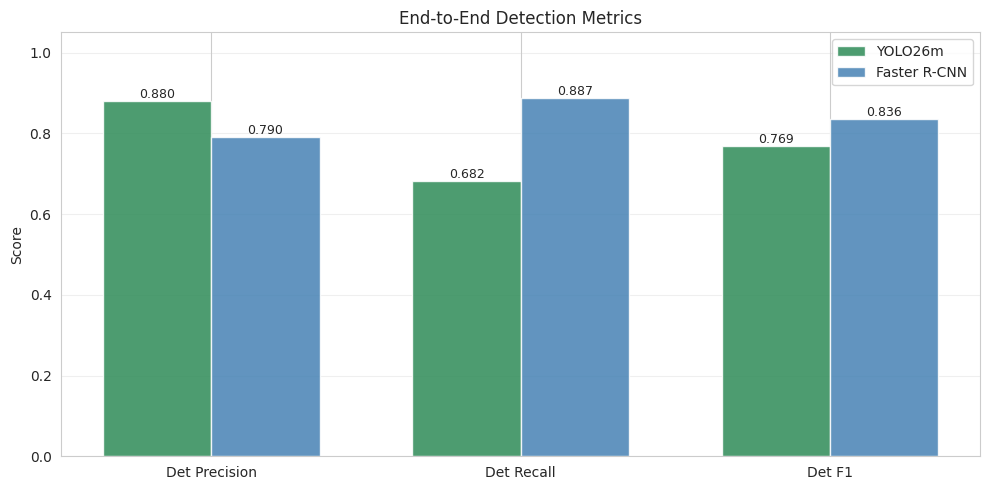

In [8]:
# Detection metrics bar chart
det_metrics = ['Det Precision', 'Det Recall', 'Det F1']
yolo_det = [yolo_metrics['det_precision'], yolo_metrics['det_recall'], yolo_metrics['det_f1']]
frcnn_det = [frcnn_metrics['det_precision'], frcnn_metrics['det_recall'], frcnn_metrics['det_f1']]

x = np.arange(len(det_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width / 2, yolo_det, width, label='YOLO26m', color='seagreen', alpha=0.85)
b2 = ax.bar(x + width / 2, frcnn_det, width, label='Faster R-CNN', color='steelblue', alpha=0.85)

ax.set_title('End-to-End Detection Metrics')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(det_metrics)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.legend()

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


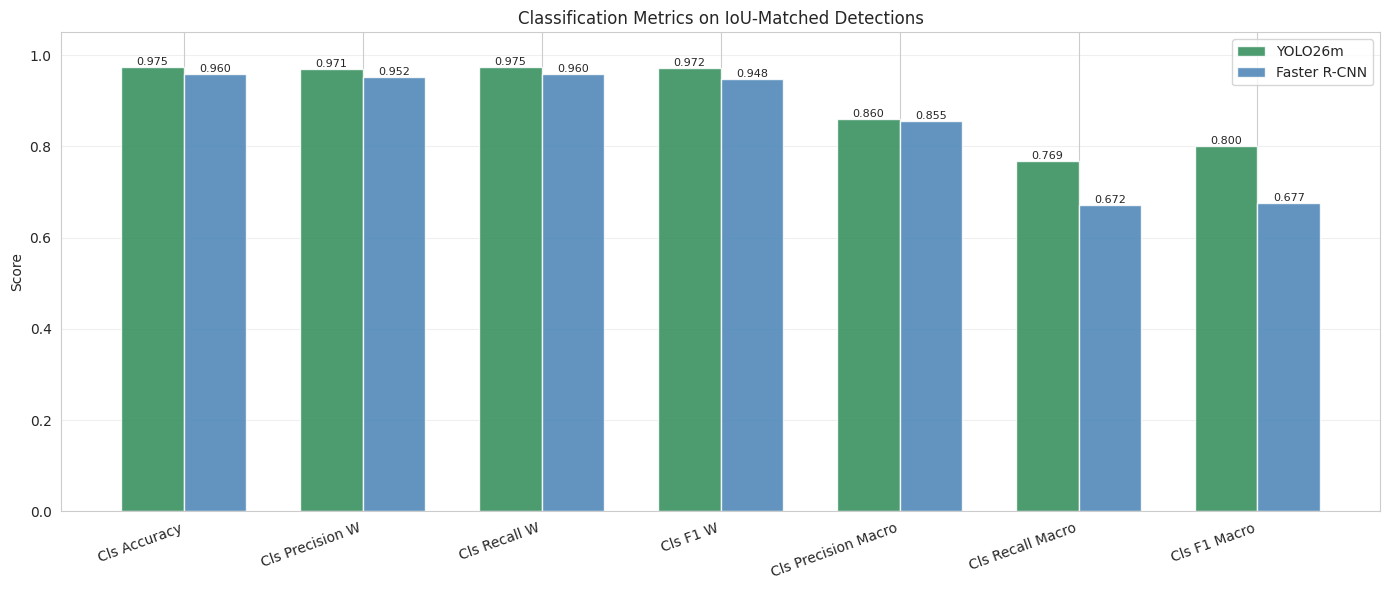

In [9]:
# Classification overall metrics (matched detections)
cls_metrics = ['Cls Accuracy', 'Cls Precision W', 'Cls Recall W', 'Cls F1 W', 'Cls Precision Macro', 'Cls Recall Macro', 'Cls F1 Macro']
yolo_cls = [
    yolo_metrics['cls_accuracy'],
    yolo_metrics['cls_precision_w'],
    yolo_metrics['cls_recall_w'],
    yolo_metrics['cls_f1_w'],
    yolo_metrics['cls_precision_macro'],
    yolo_metrics['cls_recall_macro'],
    yolo_metrics['cls_f1_macro'],
]
frcnn_cls = [
    frcnn_metrics['cls_accuracy'],
    frcnn_metrics['cls_precision_w'],
    frcnn_metrics['cls_recall_w'],
    frcnn_metrics['cls_f1_w'],
    frcnn_metrics['cls_precision_macro'],
    frcnn_metrics['cls_recall_macro'],
    frcnn_metrics['cls_f1_macro'],
]

x = np.arange(len(cls_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width / 2, yolo_cls, width, label='YOLO26m', color='seagreen', alpha=0.85)
b2 = ax.bar(x + width / 2, frcnn_cls, width, label='Faster R-CNN', color='steelblue', alpha=0.85)

ax.set_title('Classification Metrics on IoU-Matched Detections')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(cls_metrics, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.legend()

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


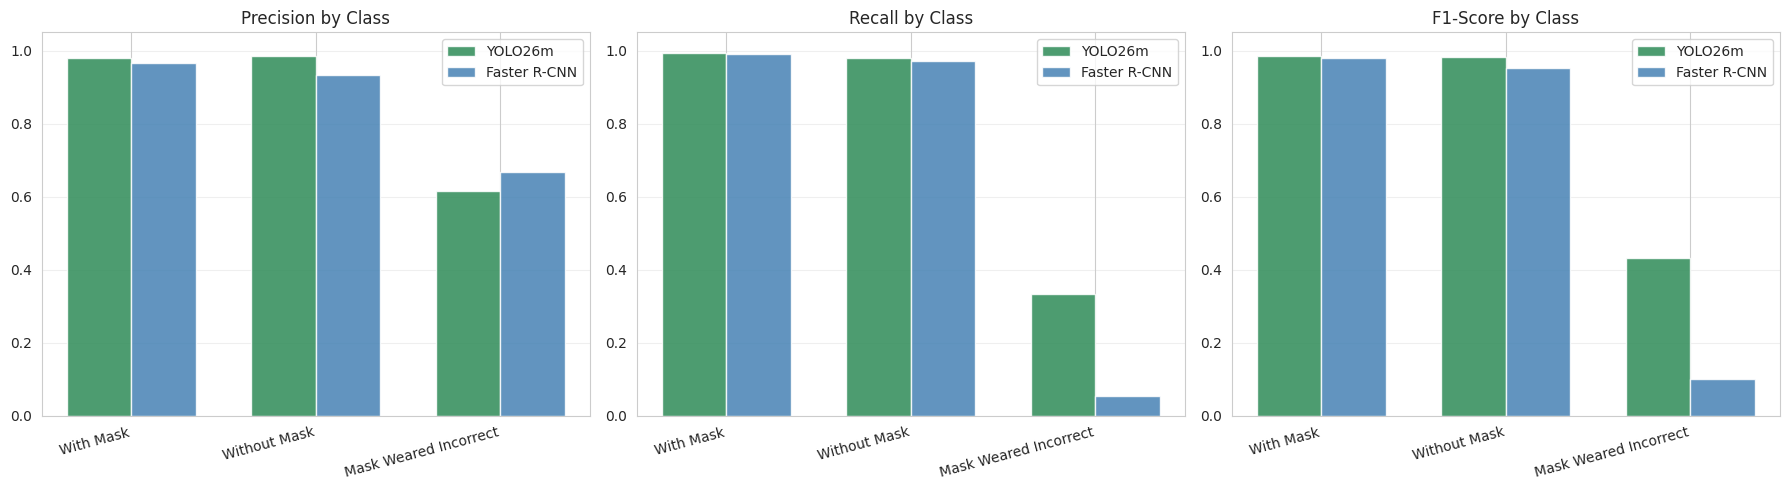

In [10]:
# Per-class metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_names = ['Precision', 'Recall', 'F1-Score']
yolo_per = [yolo_metrics['per_class_precision'], yolo_metrics['per_class_recall'], yolo_metrics['per_class_f1']]
frcnn_per = [frcnn_metrics['per_class_precision'], frcnn_metrics['per_class_recall'], frcnn_metrics['per_class_f1']]

for i, (name, yvals, fvals) in enumerate(zip(metric_names, yolo_per, frcnn_per)):
    ax = axes[i]
    x = np.arange(len(CLASS_NAMES))
    width = 0.35

    ax.bar(x - width / 2, yvals, width, label='YOLO26m', color='seagreen', alpha=0.85)
    ax.bar(x + width / 2, fvals, width, label='Faster R-CNN', color='steelblue', alpha=0.85)

    ax.set_title(f'{name} by Class')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


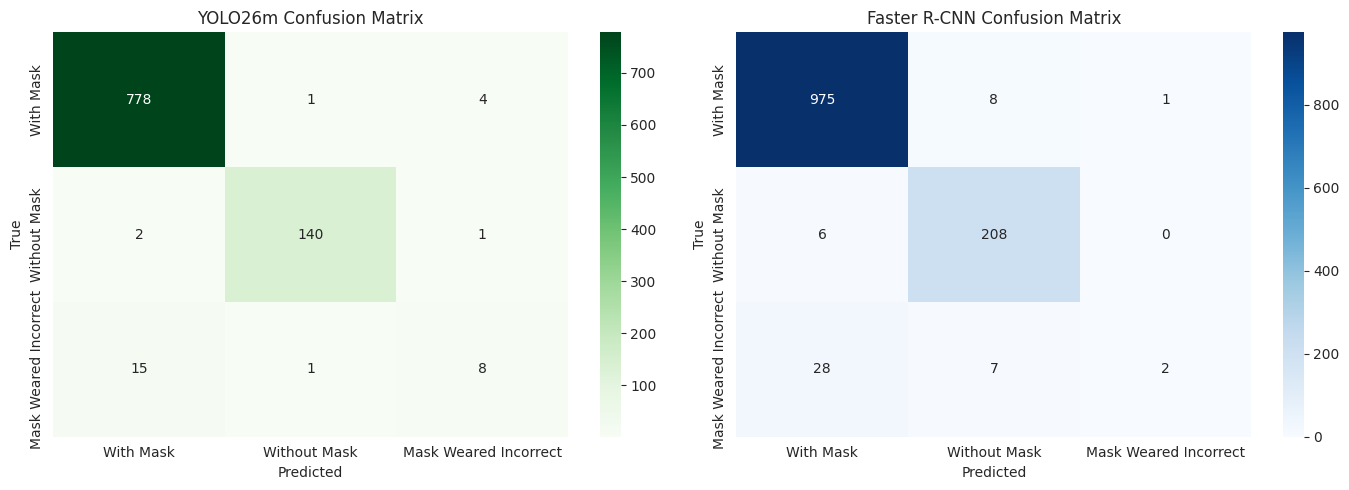

In [11]:
# Confusion matrices (matched detections)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    yolo_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[0],
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
axes[0].set_title('YOLO26m Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(
    frcnn_metrics['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
axes[1].set_title('Faster R-CNN Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()


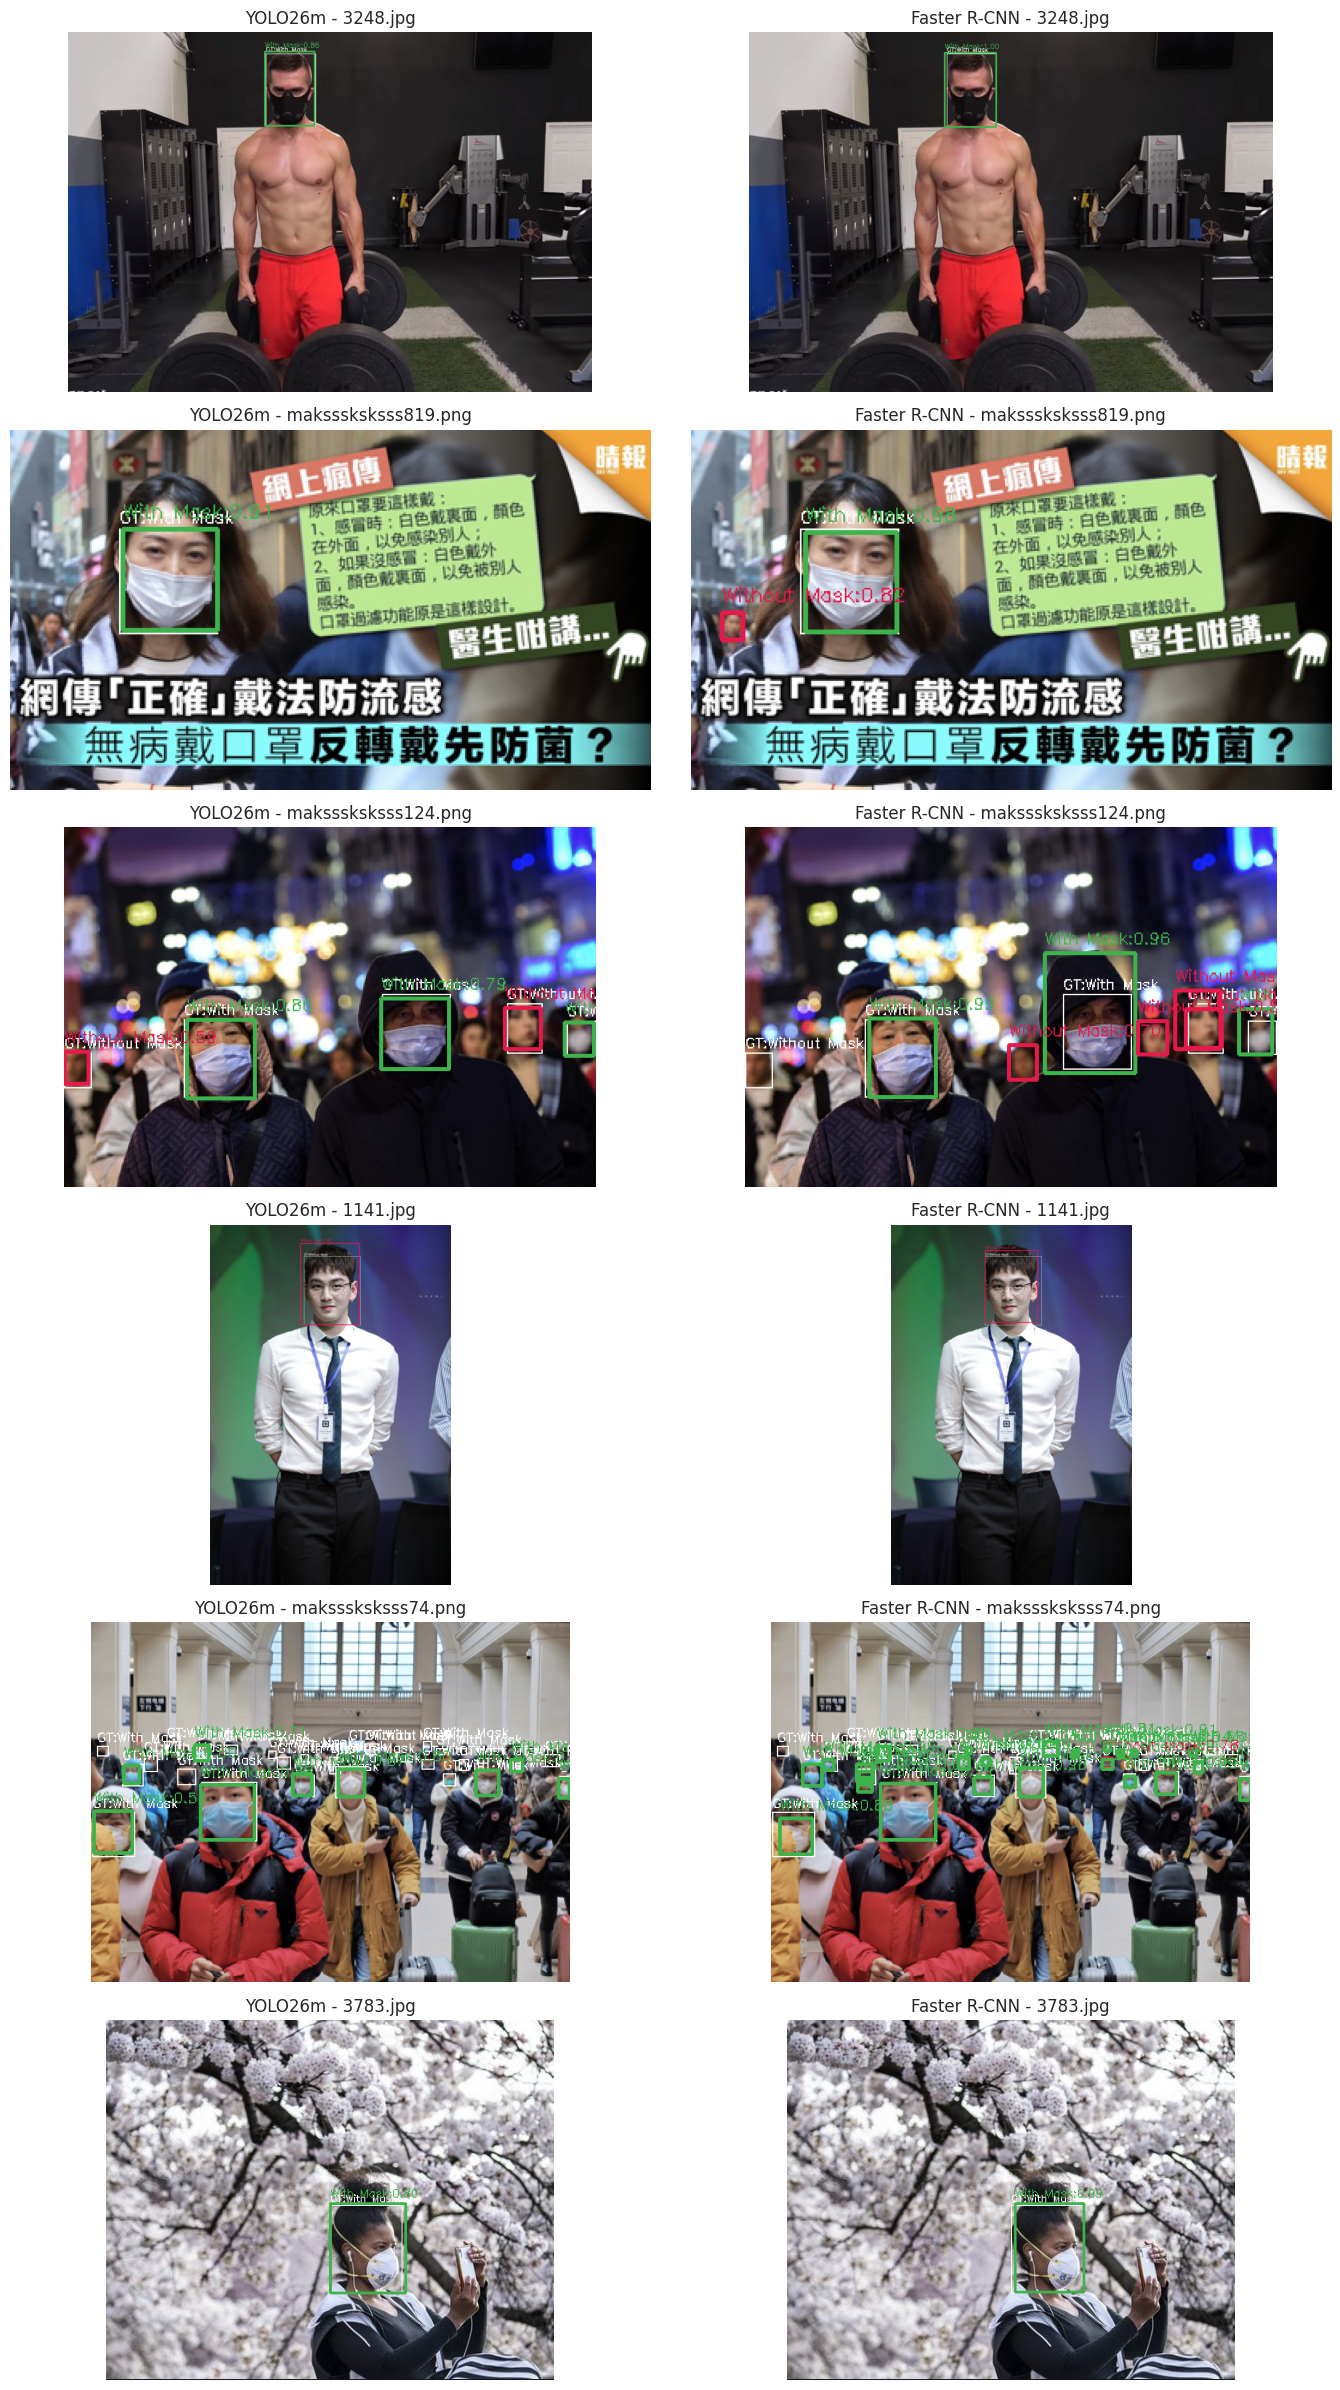

In [12]:
# Qualitative comparison on random samples
COLORS = {
    0: (60, 180, 75),   # With Mask
    1: (230, 25, 75),   # Without Mask
    2: (0, 130, 200),   # Mask Incorrect
}


def draw_boxes(image_rgb, preds, gt_raw=None, title=''):
    out = image_rgb.copy()

    # Draw GT boxes in white
    if gt_raw is not None:
        h, w = image_rgb.shape[:2]
        for cls_id, cx, cy, bw, bh in gt_raw:
            x1, y1, x2, y2 = yolo_to_pixel(cx, cy, bw, bh, w, h)
            cv2.rectangle(out, (x1, y1), (x2, y2), (255, 255, 255), 1)
            cv2.putText(out, f"GT:{CLASS_NAMES[cls_id]}", (x1, max(10, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1)

    # Draw predictions in class colors
    for p in preds:
        x1, y1, x2, y2 = p['box']
        cls_id = p['cls']
        score = p['score']
        color = COLORS.get(cls_id, (255, 255, 0))
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        cv2.putText(out, f"{CLASS_NAMES[cls_id]}:{score:.2f}", (x1, max(10, y1 - 7)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    return out


sample_count = min(6, len(test_images))
rng = np.random.RandomState(42)
sample_paths = list(rng.choice(test_images, size=sample_count, replace=False))

fig, axes = plt.subplots(sample_count, 2, figsize=(14, 4 * sample_count))
if sample_count == 1:
    axes = np.array([axes])

for row, img_path in enumerate(sample_paths):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gt_raw = read_yolo_label(TEST_LABELS_DIR / f"{img_path.stem}.txt")

    yolo_preds = predict_yolo(yolo_model, img_path, YOLO_CONF_THRESHOLD)
    frcnn_preds = predict_frcnn(frcnn_model, img_rgb, device, FRCNN_SCORE_THRESHOLD)

    yolo_img = draw_boxes(img_rgb, yolo_preds, gt_raw=gt_raw)
    frcnn_img = draw_boxes(img_rgb, frcnn_preds, gt_raw=gt_raw)

    axes[row, 0].imshow(yolo_img)
    axes[row, 0].set_title(f"YOLO26m - {img_path.name}")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(frcnn_img)
    axes[row, 1].set_title(f"Faster R-CNN - {img_path.name}")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()


In [13]:
# Detailed classification reports (matched detections)
print('=' * 90)
print('YOLO26M CLASSIFICATION REPORT (MATCHED DETECTIONS)')
print('=' * 90)
print(classification_report(yolo_metrics['y_true_cls'], yolo_metrics['y_pred_cls'], labels=[0, 1, 2], target_names=CLASS_NAMES, zero_division=0))

print('\n' + '=' * 90)
print('FASTER R-CNN CLASSIFICATION REPORT (MATCHED DETECTIONS)')
print('=' * 90)
print(classification_report(frcnn_metrics['y_true_cls'], frcnn_metrics['y_pred_cls'], labels=[0, 1, 2], target_names=CLASS_NAMES, zero_division=0))

YOLO26M CLASSIFICATION REPORT (MATCHED DETECTIONS)
                       precision    recall  f1-score   support

            With Mask       0.98      0.99      0.99       783
         Without Mask       0.99      0.98      0.98       143
Mask Weared Incorrect       0.62      0.33      0.43        24

             accuracy                           0.97       950
            macro avg       0.86      0.77      0.80       950
         weighted avg       0.97      0.97      0.97       950


FASTER R-CNN CLASSIFICATION REPORT (MATCHED DETECTIONS)
                       precision    recall  f1-score   support

            With Mask       0.97      0.99      0.98       984
         Without Mask       0.93      0.97      0.95       214
Mask Weared Incorrect       0.67      0.05      0.10        37

             accuracy                           0.96      1235
            macro avg       0.86      0.67      0.68      1235
         weighted avg       0.95      0.96      0.95      1235

